# rdinv-variant sweep: A vs B vs VN (and VN at decoupled delta)

Damping-floor reference in the kl-diag-polar (PoLoRA) large-side diagonal metric `_rdinv`:
- **A** (shipped/paper): own op-norm, `(x/x_max + delta)^(-1/2)`
- **B** (raw / KL-unbiased gauge): `(x + delta*x_max)^(-1/2)` (same op-norm floor)
- **VN** (von Neumann / matrix Adafactor): `(x + delta*Tr(partner))^(-1/2)` (trace-scaled)

`rdinv_delta` decouples the diagonal floor from the small-side C inverse-sqrt floor (`precond_delta`). Runs are labelled `VN@d<rdinv_delta>` when set; absent means coupled to precond_delta=1e-4.

Llama-3.2-1B, openmath packed seq2048, r256, 9000 steps, precond_delta=1e-4, seed 0. A reused from records; B/VN from groups rdinv_variants_lr_bw (6562227) and rdinv_vn_delta1e-6_bw (6562255).

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '/mnt/home/nghosh/lora')
import numpy as np
import matplotlib.pyplot as plt
from lora_playground.loader import load_runs

In [2]:
# COMPUTE: load every protagonist-config run, split by (variant, rdinv_delta).
# where pins each protagonist axis (A matches B/VN; excludes ablation arms). rdinv_delta
# is NOT pinned, so coupled VN (delta=1e-4) and decoupled VN (rdinv_delta=1e-6) both load.
WHERE = {
    'optimizer': 'kl-diag-polar-lora', 'lora_r': 256,
    'data_dir': 'data/openmath_instruct_2_2m_packed_seq2048_llama32',
    'model_name': 'meta-llama/Llama-3.2-1B', 'precond_delta': 1e-4, 'beta1': 0.9,
    'precond_method': 'gram_ns', 'cw_nesterov': True, 'cw_picard_iters': 1,
    'cw_no_diag_curv': False, 'cw_factor_a': 0.0, 'cw_factor_b': 0.0, 'max_steps': 9000,
}
runs = load_runs(where=WHERE, quiet=True, warn_cross_commit=False)

def _label(cfg):
    v = cfg.get('rdinv_variant', 'A'); rd = cfg.get('rdinv_delta')
    return v if rd in (None, '', 'none') else f'{v}@d{float(rd):g}'

traj = {}
for cfg, evals in runs:
    lr = float(cfg.get('lr'))
    pts = [(e['step'], e['eval_loss']) for e in evals
           if isinstance(e, dict) and e.get('eval_loss') is not None and e.get('step') is not None]
    if not pts: continue
    pts.sort(); s, l = zip(*pts); traj[(_label(cfg), lr)] = (np.array(s), np.array(l))

LABELS = sorted({lab for (lab, _) in traj})
_pal = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#17becf']
COL = {lab: _pal[i % len(_pal)] for i, lab in enumerate(LABELS)}
print(f'{len(traj)} (label, lr) trajectories; labels = {LABELS}')
for (lab, lr) in sorted(traj, key=lambda k: (k[0], k[1])):
    s, l = traj[(lab, lr)]
    print(f'  {lab:10s} lr={lr:<7g} n={len(l):3d} max_step={s.max():5d} final={l[-1]:.4f} min={l.min():.4f}')

13 (label, lr) trajectories; labels = ['A', 'B', 'VN', 'VN@d1e-06']
  A          lr=0.003   n= 36 max_step= 9000 final=0.3759 min=0.3759
  A          lr=0.01    n= 36 max_step= 9000 final=0.3644 min=0.3644
  A          lr=0.03    n= 36 max_step= 9000 final=0.3684 min=0.3684
  A          lr=0.1     n= 36 max_step= 9000 final=0.3991 min=0.3991
  B          lr=0.003   n= 36 max_step= 9000 final=0.3726 min=0.3726
  B          lr=0.01    n= 36 max_step= 9000 final=0.3675 min=0.3675
  B          lr=0.03    n= 36 max_step= 9000 final=0.3821 min=0.3821
  VN         lr=0.003   n= 36 max_step= 9000 final=0.3732 min=0.3732
  VN         lr=0.01    n= 36 max_step= 9000 final=0.3656 min=0.3656
  VN         lr=0.03    n= 36 max_step= 9000 final=0.3747 min=0.3747
  VN@d1e-06  lr=0.003   n= 36 max_step= 9000 final=0.3738 min=0.3738
  VN@d1e-06  lr=0.01    n= 36 max_step= 9000 final=0.3643 min=0.3643
  VN@d1e-06  lr=0.03    n= 36 max_step= 9000 final=0.3695 min=0.3695


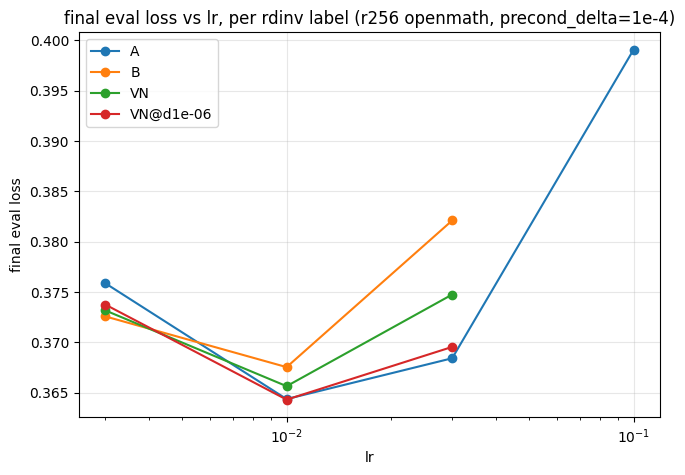

In [3]:
# PLOT 1: final eval loss vs lr, per label.
fig, ax = plt.subplots(figsize=(7.5, 5))
for lab in LABELS:
    lrs = sorted(lr for (l, lr) in traj if l == lab)
    if not lrs: continue
    ax.plot(lrs, [traj[(lab, lr)][1][-1] for lr in lrs], '-o', color=COL[lab], label=lab)
ax.set_xscale('log'); ax.set_xlabel('lr'); ax.set_ylabel('final eval loss')
ax.set_title('final eval loss vs lr, per rdinv label (r256 openmath, precond_delta=1e-4)')
ax.legend(); ax.grid(alpha=0.3); plt.show()

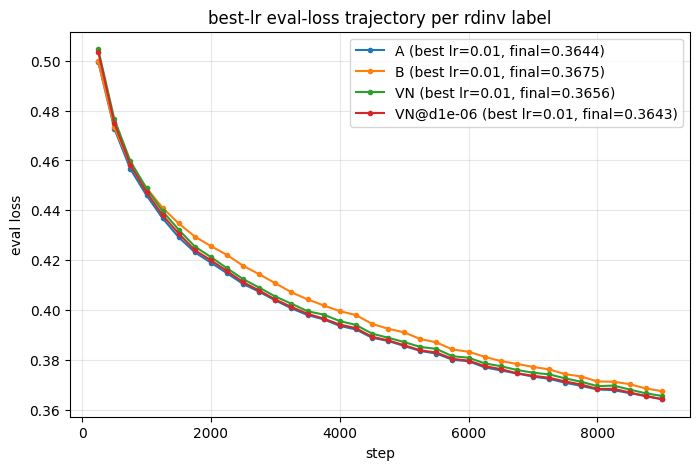

In [4]:
# PLOT 2: best-lr eval-loss trajectory per label.
fig, ax = plt.subplots(figsize=(8, 5))
for lab in LABELS:
    cells_ = [(lr, traj[(lab, lr)]) for (l, lr) in traj if l == lab]
    if not cells_: continue
    best_lr, (s, l) = min(cells_, key=lambda c: c[1][1][-1])
    ax.plot(s, l, '-o', ms=3, color=COL[lab], label=f'{lab} (best lr={best_lr:g}, final={l[-1]:.4f})')
ax.set_xlabel('step'); ax.set_ylabel('eval loss')
ax.set_title('best-lr eval-loss trajectory per rdinv label')
ax.legend(); ax.grid(alpha=0.3); plt.show()

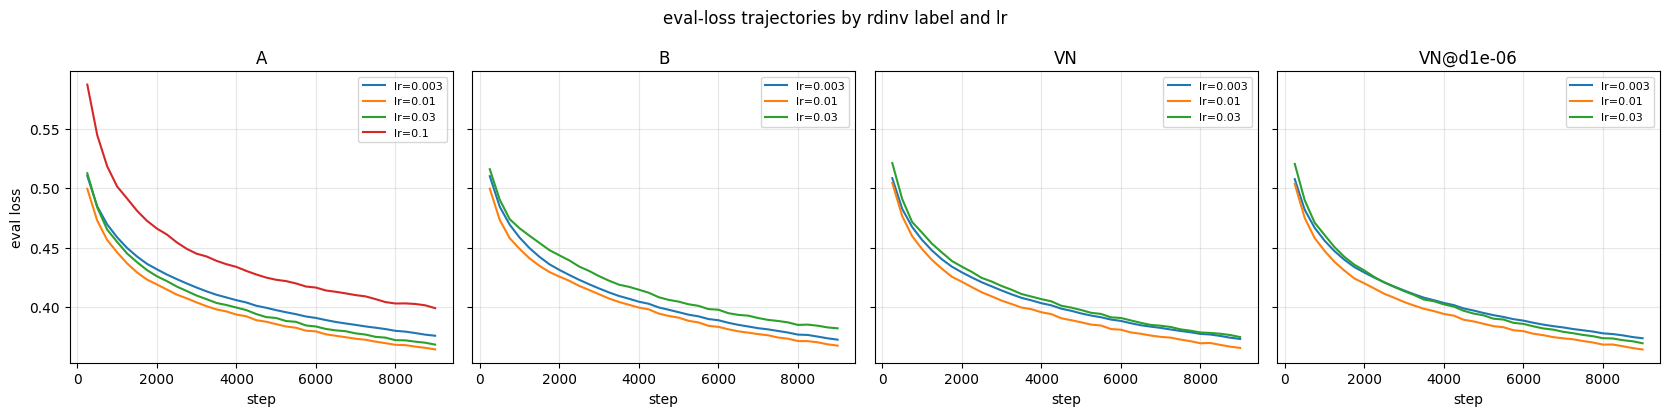

In [5]:
# PLOT 3: all (label, lr) trajectories faceted by label.
ncol = max(1, len(LABELS))
fig, axes = plt.subplots(1, ncol, figsize=(4.2*ncol, 4.2), sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, lab in zip(axes, LABELS):
    for lr in sorted(lr for (l, lr) in traj if l == lab):
        s, l = traj[(lab, lr)]; ax.plot(s, l, '-', label=f'lr={lr:g}')
    ax.set_title(lab); ax.set_xlabel('step'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel('eval loss')
fig.suptitle('eval-loss trajectories by rdinv label and lr'); fig.tight_layout(); plt.show()

## Overnight A/B cross-check (lr=0.01)
Earlier ad-hoc A-vs-B run at lr 0.01 via the polora driver (6561753=A, 6561755=B), logged to session scratch (not the loader). Overlaid (dashed) on the loader's lr=0.01 cells. Skipped if absent.

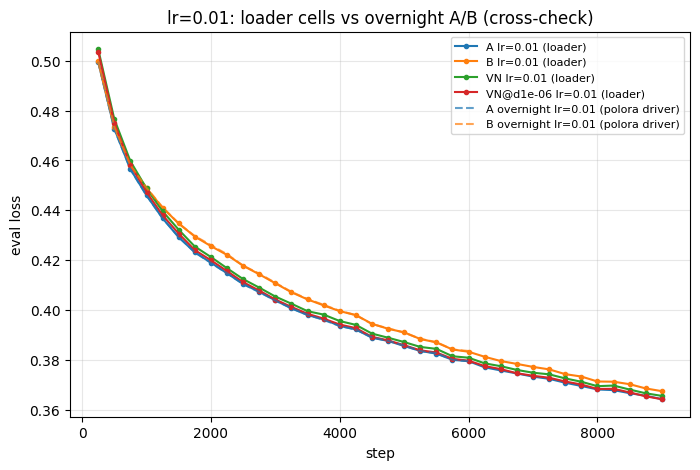

In [6]:
import json, os
OVN = '/mnt/home/nghosh/.tmp_scripts/overnight'  # local-only scratch
def _load_jsonl(p):
    if not os.path.exists(p): return None
    s, l = [], []
    for line in open(p):
        try: d = json.loads(line)
        except Exception: continue
        if d.get('event') == 'eval' and d.get('eval_loss') is not None:
            s.append(d['step']); l.append(d['eval_loss'])
    return (np.array(s), np.array(l)) if s else None
ovn = {'A': _load_jsonl(f'{OVN}/AB_A.jsonl'), 'B': _load_jsonl(f'{OVN}/AB_B.jsonl')}
fig, ax = plt.subplots(figsize=(8, 5))
for (lab, lr) in sorted(traj):
    if lr == 0.01:
        s, l = traj[(lab, lr)]; ax.plot(s, l, '-o', ms=3, color=COL[lab], label=f'{lab} lr=0.01 (loader)')
for v, c in [('A', '#1f77b4'), ('B', '#ff7f0e')]:
    if ovn.get(v) is not None:
        s, l = ovn[v]; ax.plot(s, l, '--', color=c, alpha=0.7, label=f'{v} overnight lr=0.01 (polora driver)')
    else:
        print(f'overnight {v}: local jsonl not found, skipped')
ax.set_xlabel('step'); ax.set_ylabel('eval loss')
ax.set_title('lr=0.01: loader cells vs overnight A/B (cross-check)')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()